In [2]:
import matplotlib.pyplot as plt
import json
import os

def parse_log_file(file_path):
    """Parse a log file containing JSON entries, one per line"""
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line:  # Skip empty lines
                try:
                    entry = json.loads(line)
                    data.append(entry)
                except json.JSONDecodeError:
                    print(f"Warning: Could not parse line: {line}")
    return data

def plot_metrics(file_path, metrics, output_path=None, title=None, label=None):
    """Plot specified metrics from a log file"""
    plt.figure(figsize=(12, 8))
    
    # Make sure metrics is a list
    if isinstance(metrics, str):
        metrics = [metrics]
    
    data = parse_log_file(file_path)
    
    if not data:
        print(f"Warning: No data found in {file_path}")
        return
    
    # Extract epochs
    epochs = [entry.get('epoch', i) for i, entry in enumerate(data)]
    
    # Plot each requested metric
    for metric in metrics:
        # Try to find the metric with various prefixes
        prefixes = ['', 'train_', 'test_', 'val_']
        
        for prefix in prefixes:
            full_metric = f"{prefix}{metric}"
            # Check if the metric exists in any entry
            if any(full_metric in entry for entry in data):
                values = [entry.get(full_metric, float('nan')) for entry in data]
                metric_label = f"{label} - {full_metric}" if label else full_metric
                plt.plot(epochs, values, marker='o', label=metric_label)

    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='best')
    
    if title:
        plt.title(title)
    else:
        plt.title(', '.join(metrics))
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path)
        print(f"Plot saved to {output_path}")
    else:
        plt.show()


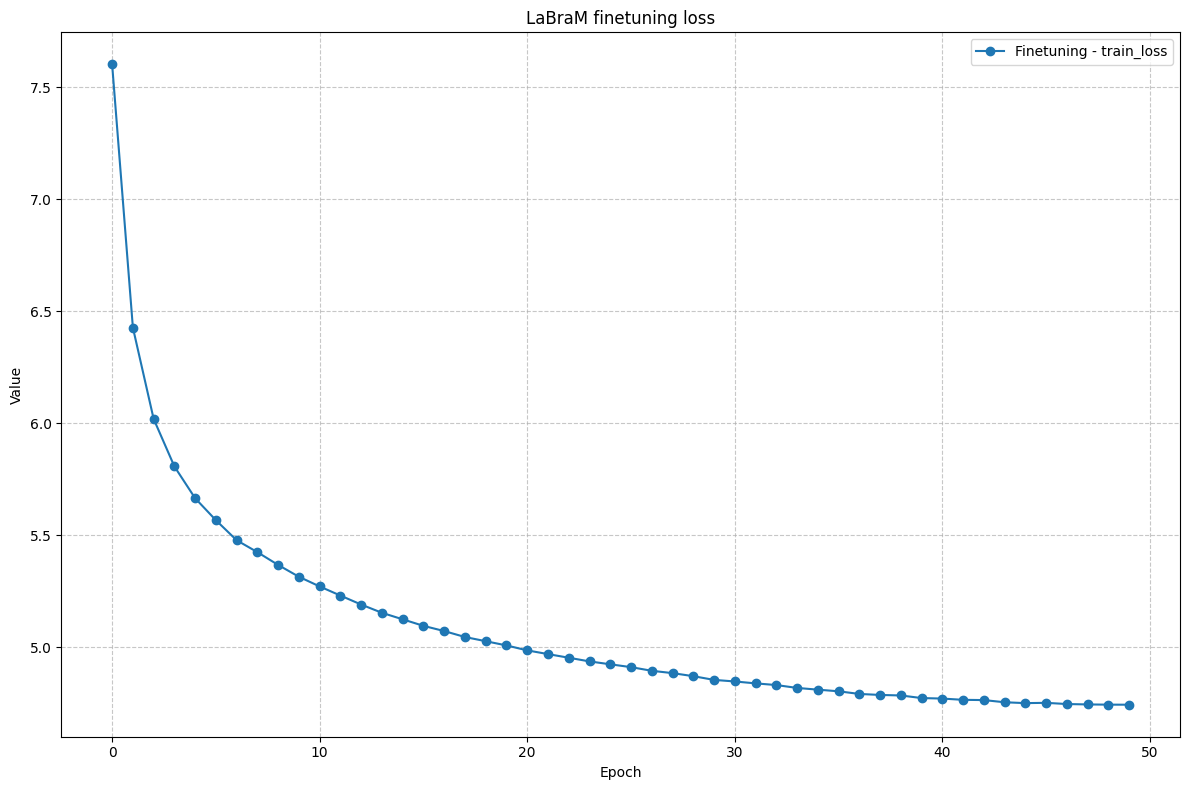

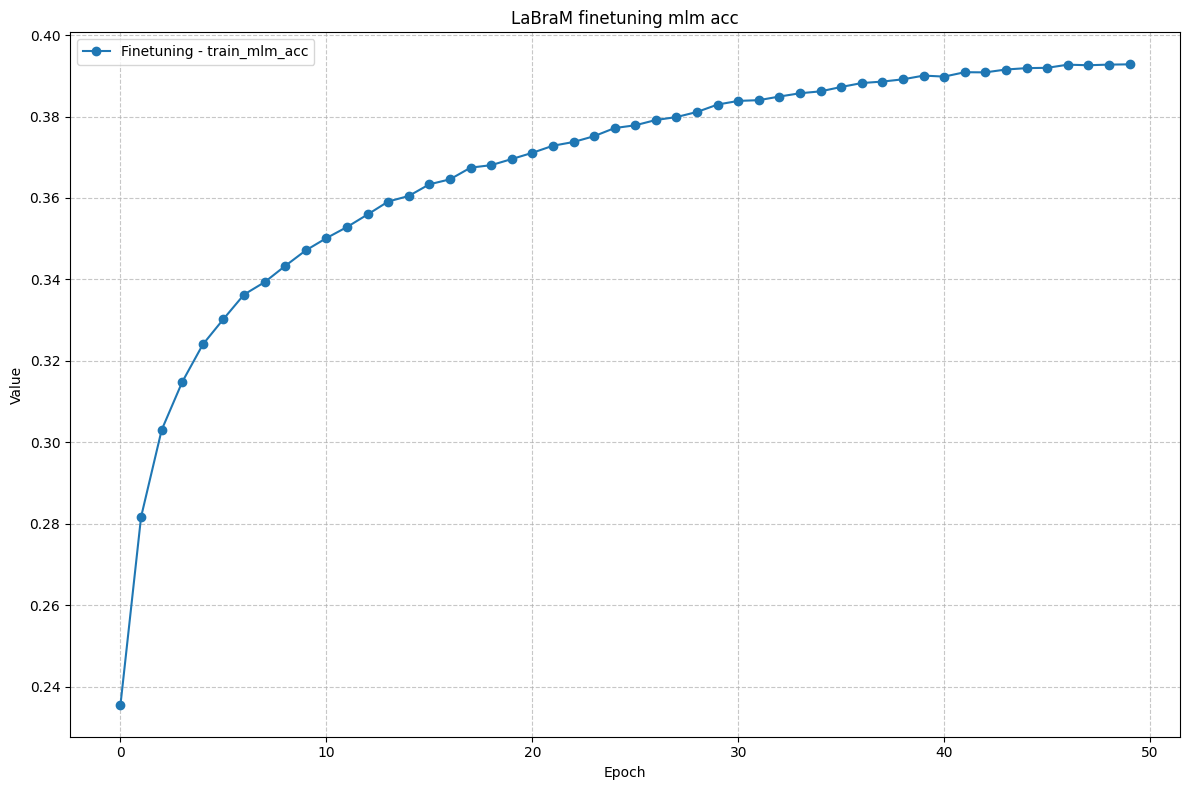

In [2]:
### Finetune labram
filepath = "/zhome/ce/8/186807/Desktop/Labram/LaBraM-MMDTU/checkpoints/finetune_dtu_labram/log.txt"
metrics = ["loss"]
title = "LaBraM finetuning loss"
labels = "Finetuning"


plot_metrics(filepath,metrics, None, title, labels)
metrics = ["mlm_acc"]
title = "LaBraM finetuning mlm acc"
labels = "Finetuning"


plot_metrics(filepath,metrics, None, title, labels)

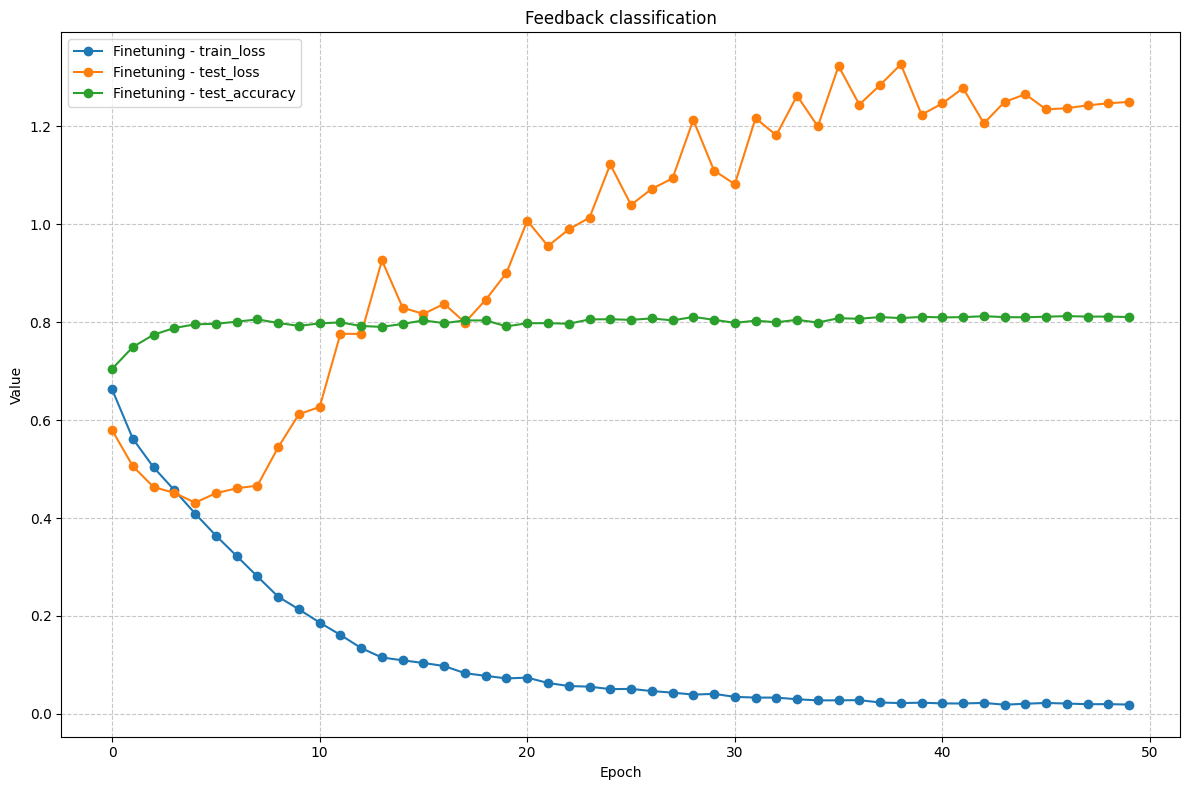

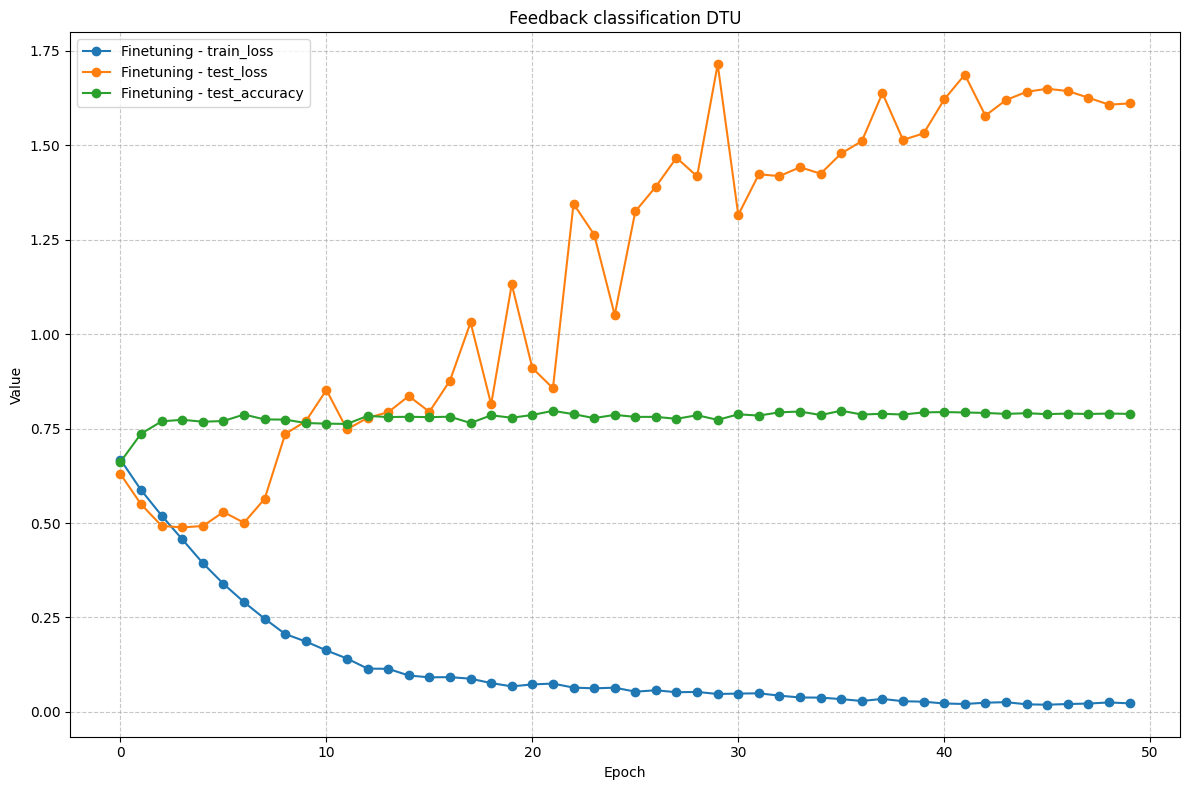

In [3]:
### Finetune labram
filepath = "/zhome/ce/8/186807/Desktop/Labram/LaBraM-MMDTU/checkpoints/finetune_dtu_base/feedback_lr5e4/log.txt"
metrics = ["loss", "accuracy"]
title = "Feedback classification"
labels = "Finetuning"

plot_metrics(filepath,metrics, None, title, labels)

filepath = "/zhome/ce/8/186807/Desktop/Labram/LaBraM-MMDTU/checkpoints/finetune_dtu_base/feedback_dtu_lr5e4/log.txt"
metrics = ["loss", "accuracy"]
title = "Feedback classification DTU"
labels = "Finetuning"

plot_metrics(filepath,metrics, None, title, labels)

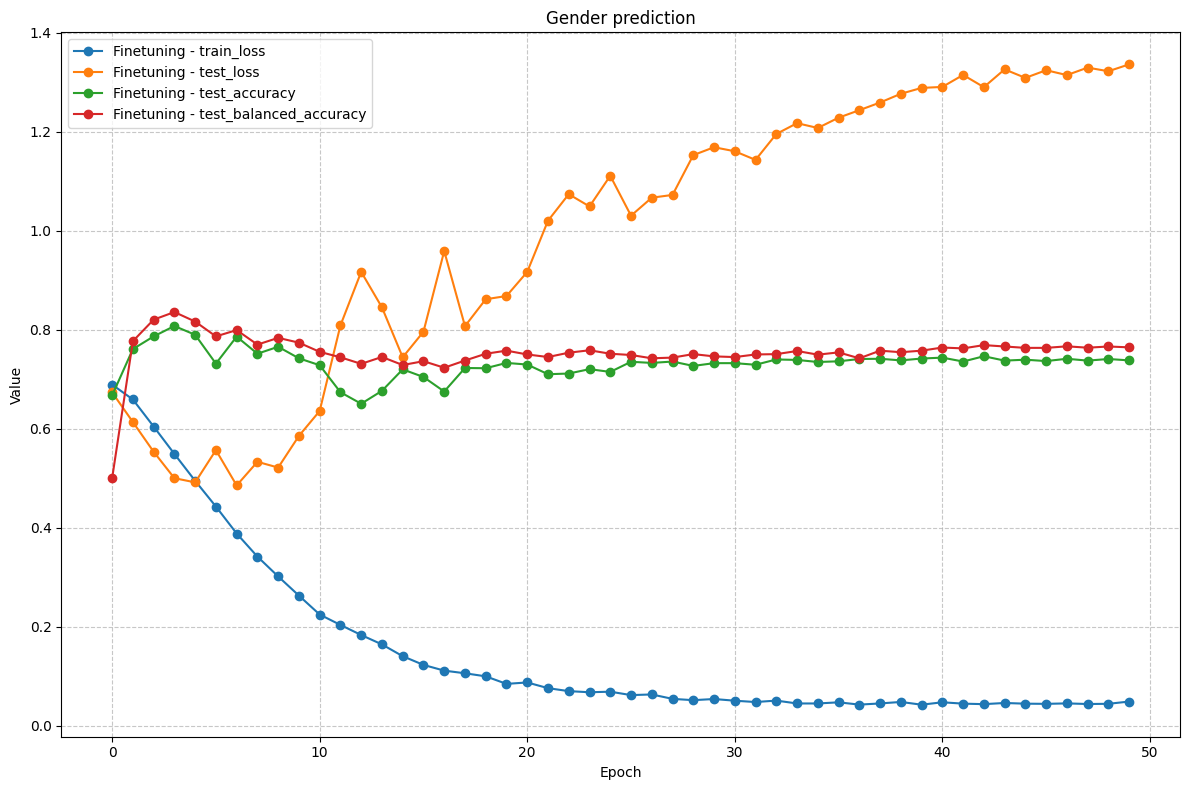

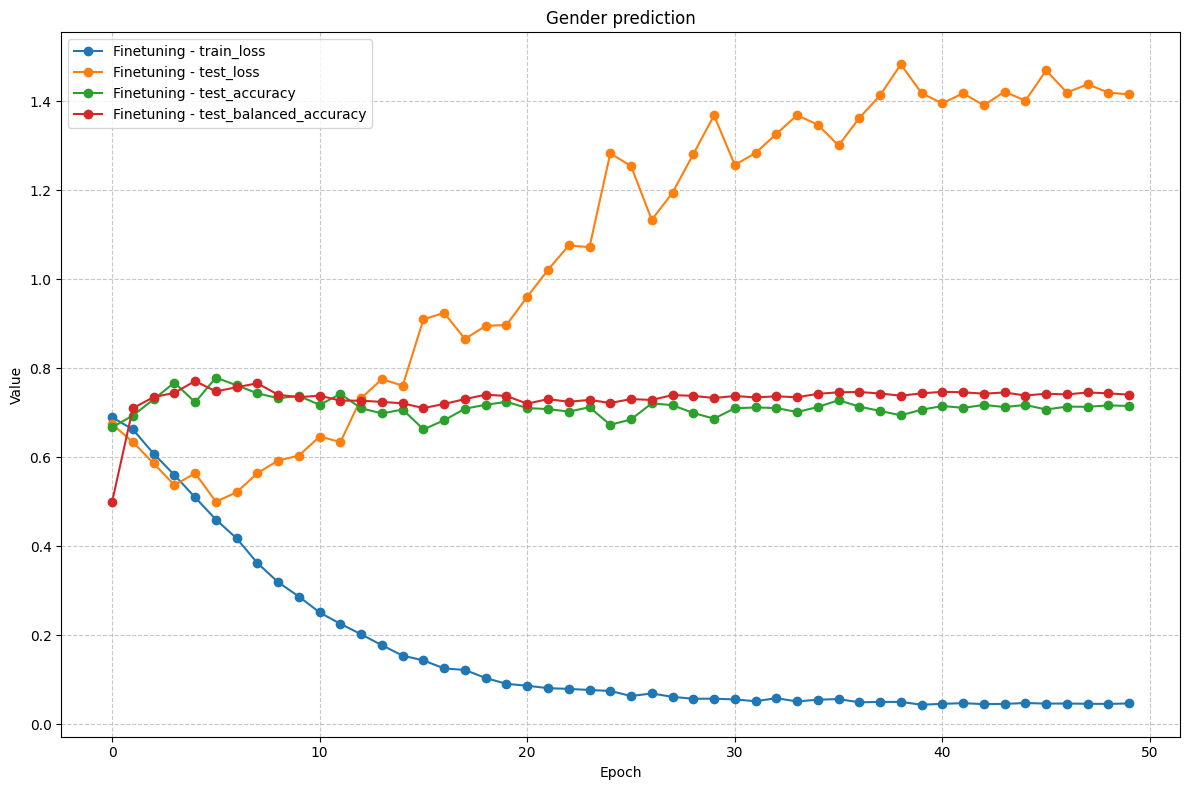

In [3]:
### Finetune labram
filepath = "/zhome/ce/8/186807/Desktop/Labram/LaBraM-MMDTU/checkpoints/finetune_dtu_base/gender_dtu_finetuned/log.txt"
metrics = ["loss", "accuracy", "balanced_accuracy"]
title = "Gender prediction"
labels = "Finetuning"

plot_metrics(filepath,metrics, None, title, labels)
filepath = "/zhome/ce/8/186807/Desktop/Labram/LaBraM-MMDTU/checkpoints/finetune_dtu_base/gender_dtu_finetuned_nofeedback/log.txt"
plot_metrics(filepath,metrics, None, title, labels)

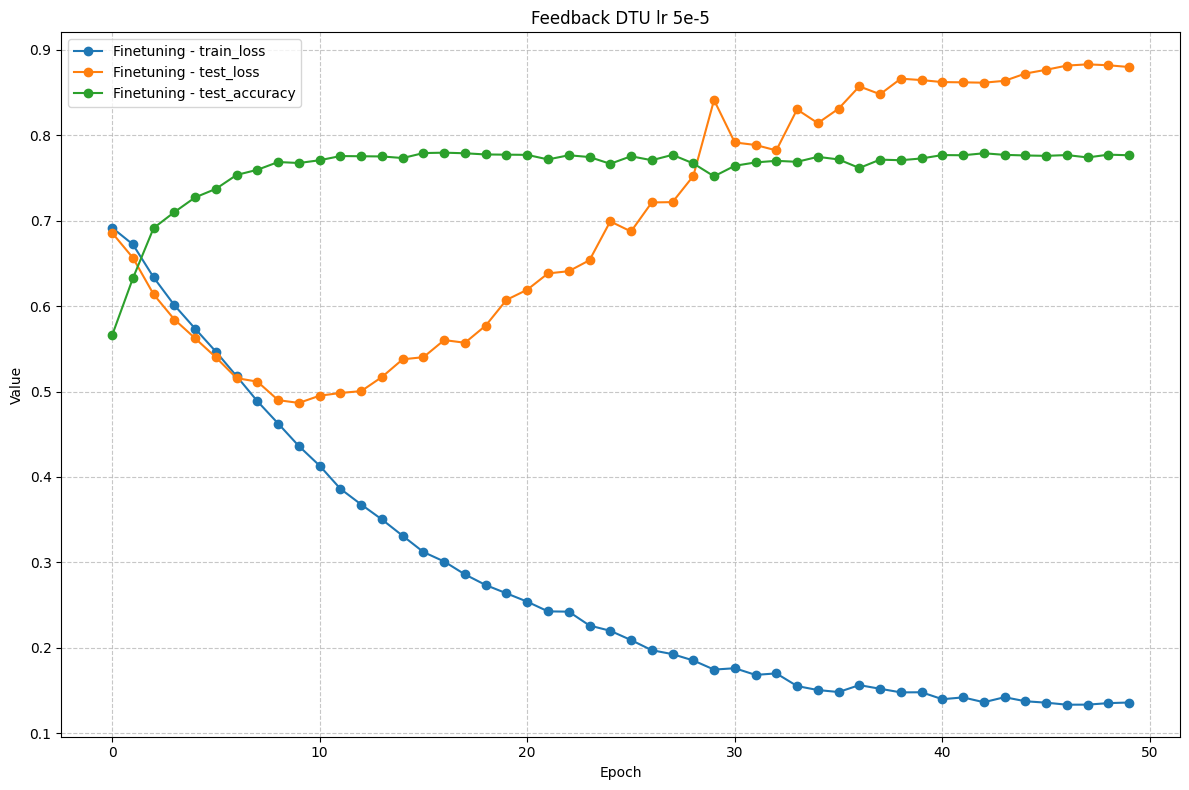

In [5]:
### Finetune labram
filepath = "/zhome/ce/8/186807/Desktop/Labram/LaBraM-MMDTU/checkpoints/finetune_dtu_base/feedback_dtu_lr5e5/log.txt"
metrics = ["loss", "accuracy"]
title = "Feedback DTU lr 5e-5"
labels = "Finetuning"


plot_metrics(filepath,metrics, None, title, labels)

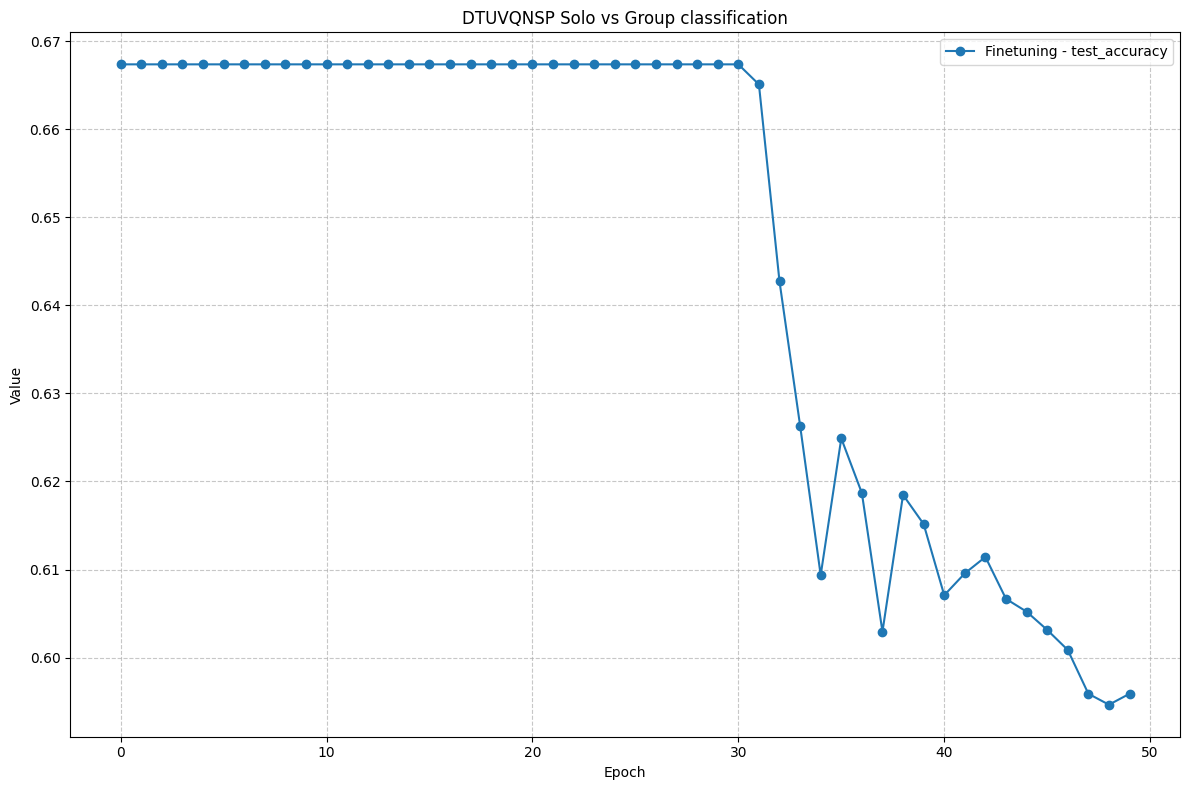

In [7]:
### Finetune labram
filepath = "/zhome/ce/8/186807/Desktop/Labram/LaBraM-MMDTU/checkpoints/finetune_dtu_base/solovsgroup_nofeedback_finetuned/log.txt"
metrics = ["accuracy"]
title = "DTUVQNSP Solo vs Group classification"
labels = "Finetuning"


plot_metrics(filepath,metrics, None, title, labels)